# Cassava Leaf Disease Classification

Классификация болезней листьев маниоки по фотографии. Пять этапов: постановка задачи, данные, эксперименты, анализ, упаковка.

**Запуск в Kaggle:** Add Input → Competition `cassava-leaf-disease-classification` (нужно принять правила), Accelerator → GPU, Internet → On (скачиваются веса pretrained-модели и пакеты).

Результат работы ноутбука — каталог `/kaggle/working/cassava_project` с моделью, конфигурацией, `inference.py`, ONNX, README и рисунками.

## Этап 1. Постановка задачи

**Пользователь.** Агроном или фермер, который фотографирует лист маниоки на телефон и хочет понять, чем болеет растение, чтобы решить, нужна ли обработка.

**Вход.** Одна RGB-фотография листа. Оригинальный размер в датасете 800×600 пикселей, в модель подаётся уменьшенная до 256×256.

**Выход.** Один из 5 классов и вероятность каждого класса:
`0` CBB (бактериальная гниль), `1` CBSD (коричневая полосатость), `2` CGM (зелёная мозаика), `3` CMD (мозаичная болезнь), `4` Healthy (здоров).

**Метрики.**
- Основная — accuracy: доля фотографий с верно угаданным классом. Это метрика соревнования, и она понятна пользователю: из 100 снимков модель права в столько-то случаев.
- Дополнительная — macro-F1: F1 считается отдельно для каждого класса и усредняется без учёта размера класса. Пример: если редкий класс CGM (около 10% снимков) почти не угадывается, accuracy упадёт слабо, а macro-F1 упадёт заметно.
- Дополнительная — recall по каждому классу: доля больных листьев класса, которые модель нашла. Пропущенная болезнь для пользователя дороже ложной тревоги.

**Критерий успеха** (задан до экспериментов): accuracy на test ≥ 0.85, macro-F1 ≥ 0.75, обе метрики выше baseline.

**Ограничения.** Размер файла модели ≤ 50 МБ, инференс одного снимка на CPU ≤ 500 мс. Проверяются в конце ноутбука.

In [1]:
!pip install -q imagehash onnx onnxruntime tabulate

import os, sys, json, time, random, hashlib, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import torch
import torch.nn as nn
import timm
import imagehash
from torchvision.transforms import v2 as T
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEED = 42
DATA = Path('/kaggle/input/competitions/cassava-leaf-disease-classification')
OUT = Path('/kaggle/working/cassava_project')
CACHE = Path('/kaggle/working/cache')
CKPT = OUT / 'checkpoints'
FIG = OUT / 'figures'
for d in (CACHE, CKPT, FIG):
    d.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
AMP = DEVICE == 'cuda'


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything()
print(DEVICE, torch.__version__, timm.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 81.3 MB/s eta 0:00:00
cuda 2.11.0+cu128 1.0.29


## Этап 2. Данные

Предобработка вынесена в модуль `preprocess.py`. Тот же файл импортирует `inference.py`, поэтому обучение и применение модели изменяют размер снимка одним и тем же кодом.

In [2]:
%%writefile /kaggle/working/cassava_project/preprocess.py
from PIL import Image

IMG_SIZE = 256
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)


def resize(img, size=IMG_SIZE):
    return img.convert('RGB').resize((size, size), Image.BILINEAR)


def load_image(path, size=IMG_SIZE):
    return resize(Image.open(path), size)

Writing /kaggle/working/cassava_project/preprocess.py


In [3]:
sys.path.insert(0, str(OUT))
from preprocess import IMG_SIZE, MEAN, STD, resize

df = pd.read_csv(DATA / 'train.csv')
names = {int(k): v for k, v in json.load(open(DATA / 'label_num_to_disease_map.json')).items()}
CLASSES = [names[i] for i in range(5)]
df['label_name'] = df.label.map(names)
print(len(df))
df.head()

21397


,image_id,label,label_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)


Один проход по всем снимкам: md5 файла (точные копии), perceptual hash (хеш по содержимому картинки, у почти одинаковых снимков он совпадает, даже если файлы разные по байтам), размер, средняя яркость. Заодно сохраняется уменьшенная копия 256×256 в PNG без потерь: чтение 21 тысячи оригиналов 800×600 на каждой эпохе заняло бы больше времени, чем сам расчёт сети.

In [4]:
def cache_path(name):
    return CACHE / (Path(name).stem + '.png')


def process(name):
    img = Image.open(DATA / 'train_images' / name)
    md5 = hashlib.md5((DATA / 'train_images' / name).read_bytes()).hexdigest()
    w, h = img.size
    small = resize(img)
    small.save(cache_path(name))
    return dict(image_id=name, md5=md5, phash=str(imagehash.phash(img)), w=w, h=h,
                brightness=float(np.asarray(small).mean()))


meta = pd.DataFrame(Parallel(n_jobs=-1)(delayed(process)(n) for n in tqdm(df.image_id)))
df = df.merge(meta, on='image_id')
df.to_csv(OUT / 'train_meta.csv', index=False)

  0%|          | 0/21397 [00:00<?, ?it/s]

### EDA: баланс классов и размеры

                                         n  share
label_name                                       
Cassava Mosaic Disease (CMD)         13158  0.615
Healthy                               2577  0.120
Cassava Green Mottle (CGM)            2386  0.112
Cassava Brown Streak Disease (CBSD)   2189  0.102
Cassava Bacterial Blight (CBB)        1087  0.051
Counter({(800, 600): 21397})


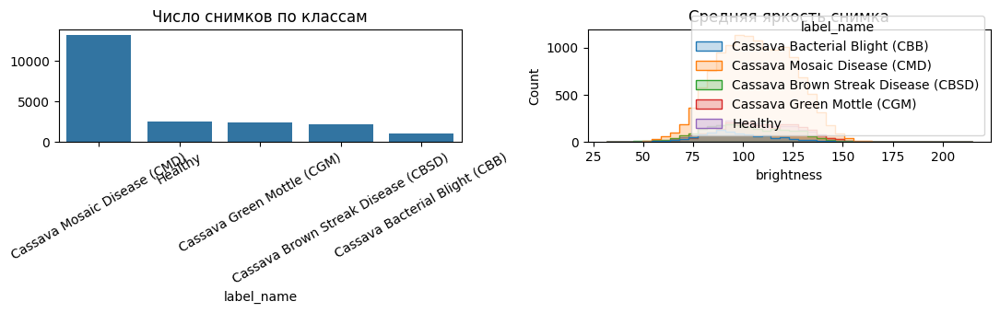

In [5]:
counts = df.label_name.value_counts()
print(pd.DataFrame({'n': counts, 'share': (counts / len(df)).round(3)}))
print(Counter(zip(df.w, df.h)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.barplot(x=counts.index, y=counts.values, ax=ax[0])
ax[0].set_title('Число снимков по классам')
ax[0].tick_params(axis='x', rotation=30)
sns.histplot(data=df, x='brightness', hue='label_name', bins=40, ax=ax[1], element='step')
ax[1].set_title('Средняя яркость снимка')
plt.tight_layout()
fig.savefig(FIG / 'eda_classes_brightness.png', dpi=120)

### Визуальная проверка разметки
По 4 случайных снимка каждого класса.

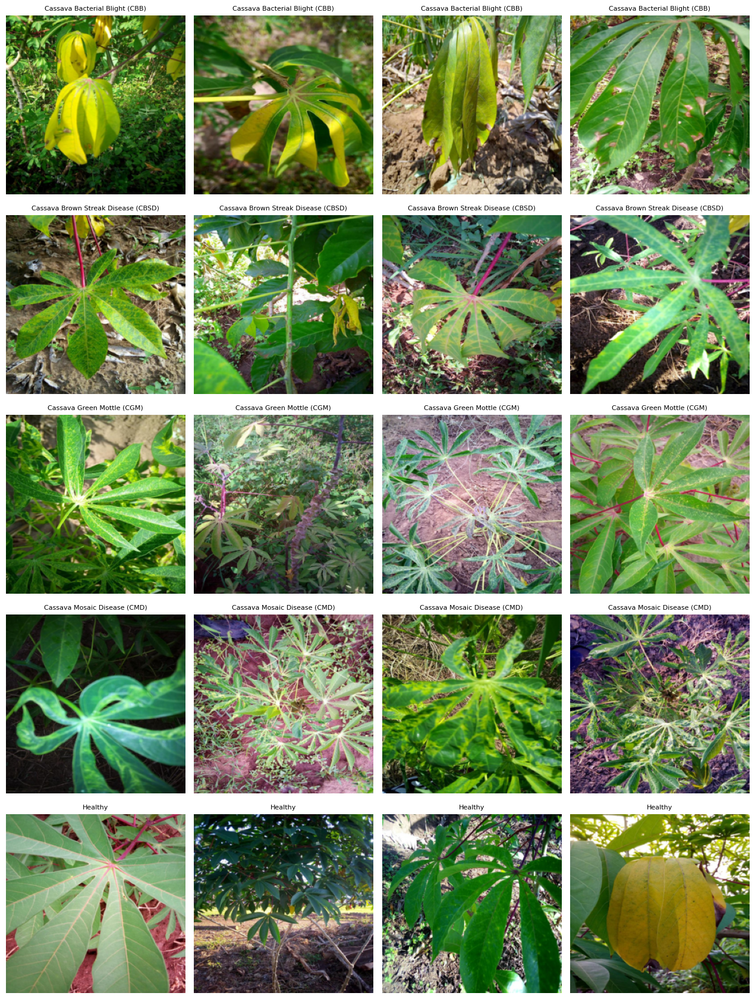

In [6]:
def show_grid(frame, titles, cols=4, path=None):
    rows = int(np.ceil(len(frame) / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.4 * rows))
    axs = np.ravel(axs)
    for ax in axs:
        ax.axis('off')
    for ax, (_, r), t in zip(axs, frame.iterrows(), titles):
        ax.imshow(Image.open(cache_path(r.image_id)))
        ax.set_title(t, fontsize=8)
    plt.tight_layout()
    if path:
        fig.savefig(path, dpi=120)


sample = df.groupby('label', group_keys=False).sample(4, random_state=SEED).sort_values('label')
show_grid(sample, sample.label_name, path=FIG / 'eda_samples.png')

### Дубликаты и подозрительные примеры
- точные копии: одинаковый md5;
- визуальные дубликаты: одинаковый perceptual hash;
- конфликт разметки: снимки с одним хешем, но разными метками (одна из двух меток заведомо неверна);
- слишком тёмные и слишком светлые снимки.

In [7]:
print('точных копий файлов:', df.md5.duplicated().sum())
print('визуальных дубликатов:', df.phash.duplicated().sum())
g = df.groupby('phash').label.nunique()
conflict_hashes = g[g > 1].index
print('групп с конфликтом меток:', len(conflict_hashes))

точных копий файлов: 0
визуальных дубликатов: 0
групп с конфликтом меток: 0


### Решения по данным
1. Split: `StratifiedGroupKFold` на 10 частей. Группа — это perceptual hash, стратификация — по классу, так что доли классов в частях близки. Часть 0 — test (≈10%), часть 1 — validation (≈10%), остальное — train (≈80%).
2. Дисбаланс (CMD ≈ 61%) не исправляется пересэмплированием; следим за macro-F1 и recall по классам.

In [8]:
df = df[~df.phash.isin(conflict_hashes)].reset_index(drop=True)
df['group'] = pd.factorize(df.phash)[0]

sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
df['fold'] = -1
for f, (_, idx) in enumerate(sgkf.split(df, df.label, df.group)):
    df.loc[idx, 'fold'] = f
df['split'] = np.select([df.fold == 0, df.fold == 1], ['test', 'val'], 'train')

for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    assert not set(df[df.split == a].group) & set(df[df.split == b].group)

print(df.split.value_counts())
print(pd.crosstab(df.split, df.label_name, normalize='index').round(3))
df.to_csv(OUT / 'split.csv', index=False)

split
train    17117
val       2140
test      2140
Name: count, dtype: int64
label_name  Cassava Bacterial Blight (CBB)  \
split                                        
test                                 0.055   
train                                0.050   
val                                  0.051   

label_name  Cassava Brown Streak Disease (CBSD)  Cassava Green Mottle (CGM)  \
split                                                                         
test                                      0.089                       0.118   
train                                     0.105                       0.110   
val                                       0.097                       0.114   

label_name  Cassava Mosaic Disease (CMD)  Healthy  
split                                              
test                               0.619    0.119  
train                              0.613    0.122  
val                                0.629    0.108  


### Transforms
Train: случайный кроп, отражения, небольшое изменение яркости, контраста и насыщенности. Validation и test: только перевод в тензор и нормализация со средним и стандартным отклонением ImageNet. Все параметры нормализации задаются константами из `preprocess.py` и не считаются по val/test.

In [9]:
train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0), antialias=True),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(0.2, 0.2, 0.2),
    T.ToImage(), T.ToDtype(torch.float32, scale=True), T.Normalize(MEAN, STD),
])
val_tf = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True), T.Normalize(MEAN, STD)])


class CassavaDS(torch.utils.data.Dataset):
    def __init__(self, frame, tf):
        self.names, self.y, self.tf = frame.image_id.values, frame.label.values, tf

    def __len__(self):
        return len(self.names)

    def __getitem__(self, i):
        return self.tf(Image.open(cache_path(self.names[i])).convert('RGB')), int(self.y[i])


def make_loader(ds, shuffle=False, bs=64):
    return torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=4,
                                       pin_memory=True, drop_last=shuffle, persistent_workers=shuffle)


train_df, val_df = df[df.split == 'train'], df[df.split == 'val']
train_dl = make_loader(CassavaDS(train_df, train_tf), shuffle=True)
val_dl = make_loader(CassavaDS(val_df, val_tf))

## Этап 3. Модели и эксперименты

Test в этом этапе не используется: все решения принимаются по validation.

| № | Гипотеза | Что меняется относительно предыдущего |
|---|----------|----------------------------------------|
| 0 | Нижняя граница: всегда предсказывать самый частый класс | — |
| 1 | Простая CNN с нуля даёт baseline | — |
| 2 | Pretrained EfficientNet-B0 лучше сети с нуля | модель |
| 3 | Label smoothing 0.1 помогает при шумной разметке | функция потерь |
| 4 | Более крупная EfficientNet-B2 лучше B0 | модель |

Label smoothing: вместо метки `[0, 1, 0, 0, 0]` сеть обучается на `[0.025, 0.9, 0.025, 0.025, 0.025]`, то есть не требует стопроцентной уверенности там, где метка может быть ошибочной. В Cassava разметка шумная (отдельные снимки размечены разными людьми по-разному).

In [10]:
results = []


def metrics(logits, y):
    p, y = logits.argmax(1).numpy(), y.numpy()
    return accuracy_score(y, p), f1_score(y, p, average='macro')


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    logits, ys = [], []
    for x, y in loader:
        with torch.autocast(DEVICE, enabled=AMP):
            logits.append(model(x.to(DEVICE, non_blocking=True)).float().cpu())
        ys.append(y)
    return torch.cat(logits), torch.cat(ys)


def run(name, arch, build, epochs, lr, smoothing=0.0, hypothesis=''):
    seed_everything()
    model = build().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs * len(train_dl))
    scaler = torch.amp.GradScaler(enabled=AMP)
    crit = nn.CrossEntropyLoss(label_smoothing=smoothing)
    best = dict(val_acc=-1)
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        loss_sum = 0
        for x, y in tqdm(train_dl, leave=False):
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with torch.autocast(DEVICE, enabled=AMP):
                loss = crit(model(x), y)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sched.step()
            loss_sum += loss.item()
        acc, f1 = metrics(*evaluate(model, val_dl))
        print(f'{name} ep{ep} loss={loss_sum / len(train_dl):.4f} val_acc={acc:.4f} val_f1={f1:.4f}')
        if acc > best['val_acc']:
            best = dict(val_acc=acc, val_f1=f1, best_epoch=ep)
            torch.save(model.state_dict(), CKPT / f'{name}.pt')
    results.append(dict(name=name, arch=arch, hypothesis=hypothesis, epochs=epochs, lr=lr, smoothing=smoothing,
                        params_m=round(sum(p.numel() for p in model.parameters()) / 1e6, 2),
                        train_min=round((time.time() - t0) / 60, 1), **best))
    del model
    torch.cuda.empty_cache()


mode = train_df.label.mode()[0]
maj = np.full(len(val_df), mode)
results.append(dict(name='exp0_majority', arch='majority', hypothesis='самый частый класс', epochs=0, lr=0, smoothing=0,
                    params_m=0, train_min=0, val_acc=accuracy_score(val_df.label, maj),
                    val_f1=f1_score(val_df.label, maj, average='macro'), best_epoch=0))

In [11]:
def small_cnn():
    def block(i, o):
        return nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))
    return nn.Sequential(block(3, 32), block(32, 64), block(64, 128), block(128, 256),
                         nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(256, 5))


def pretrained(arch):
    return lambda: timm.create_model(arch, pretrained=True, num_classes=5)


run('exp1_small_cnn', 'small_cnn', small_cnn, epochs=8, lr=1e-3, hypothesis='CNN с нуля (baseline)')

  0%|          | 0/267 [00:00<?, ?it/s]

exp1_small_cnn ep0 loss=1.0067 val_acc=0.6640 val_f1=0.3032


  0%|          | 0/267 [00:00<?, ?it/s]

exp1_small_cnn ep1 loss=0.8907 val_acc=0.5752 val_f1=0.3688


  0%|          | 0/267 [00:00<?, ?it/s]

...

exp1_small_cnn ep5 loss=0.7107 val_acc=0.7477 val_f1=0.5579


  0%|          | 0/267 [00:00<?, ?it/s]

exp1_small_cnn ep6 loss=0.6767 val_acc=0.7374 val_f1=0.5348


  0%|          | 0/267 [00:00<?, ?it/s]

exp1_small_cnn ep7 loss=0.6608 val_acc=0.7519 val_f1=0.5496


In [12]:
run('exp2_effb0', 'efficientnet_b0', pretrained('efficientnet_b0'), epochs=6, lr=5e-4,
    hypothesis='pretrained EfficientNet-B0')

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

  0%|          | 0/267 [00:00<?, ?it/s]

/tmp/ipykernel_23/36917839.py:40: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


exp2_effb0 ep0 loss=0.7478 val_acc=0.7864 val_f1=0.6561


...

exp2_effb0 ep3 loss=0.3171 val_acc=0.8430 val_f1=0.7208


  0%|          | 0/267 [00:00<?, ?it/s]

exp2_effb0 ep4 loss=0.2672 val_acc=0.8364 val_f1=0.7032


  0%|          | 0/267 [00:00<?, ?it/s]

exp2_effb0 ep5 loss=0.2220 val_acc=0.8383 val_f1=0.7068


In [13]:
run('exp3_effb0_ls', 'efficientnet_b0', pretrained('efficientnet_b0'), epochs=6, lr=5e-4, smoothing=0.1,
    hypothesis='+ label smoothing 0.1')

  0%|          | 0/267 [00:00<?, ?it/s]

exp3_effb0_ls ep0 loss=1.0334 val_acc=0.7607 val_f1=0.6025


  0%|          | 0/267 [00:00<?, ?it/s]

exp3_effb0_ls ep1 loss=0.7307 val_acc=0.7836 val_f1=0.6295


  0%|          | 0/267 [00:00<?, ?it/s]

...

exp3_effb0_ls ep3 loss=0.6324 val_acc=0.8299 val_f1=0.7046


  0%|          | 0/267 [00:00<?, ?it/s]

exp3_effb0_ls ep4 loss=0.5985 val_acc=0.8322 val_f1=0.6948


  0%|          | 0/267 [00:00<?, ?it/s]

exp3_effb0_ls ep5 loss=0.5761 val_acc=0.8322 val_f1=0.6978


In [14]:
run('exp4_effb2_ls', 'efficientnet_b2', pretrained('efficientnet_b2'), epochs=6, lr=5e-4, smoothing=0.1,
    hypothesis='B0 -> B2')

model.safetensors: reconstructing file:   0%|          |  0.00B / 36.8MB            

model.safetensors: downloading bytes:           |  0.00B            

  0%|          | 0/267 [00:00<?, ?it/s]

/tmp/ipykernel_23/36917839.py:40: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


exp4_effb2_ls ep0 loss=1.0080 val_acc=0.6519 val_f1=0.5296


...

exp4_effb2_ls ep3 loss=0.6068 val_acc=0.7874 val_f1=0.6511


  0%|          | 0/267 [00:00<?, ?it/s]

exp4_effb2_ls ep4 loss=0.5694 val_acc=0.7621 val_f1=0.6386


  0%|          | 0/267 [00:00<?, ?it/s]

exp4_effb2_ls ep5 loss=0.5440 val_acc=0.7757 val_f1=0.6470


In [15]:
res = pd.DataFrame(results)
res.to_csv(OUT / 'experiments.csv', index=False)
res

,name,arch,hypothesis,epochs,lr,smoothing,params_m,train_min,val_acc,val_f1,best_epoch
0,exp0_majority,majority,самый частый класс,0,0.0000,0.0,0.00,0.0,0.628505,0.154376,0
1,exp1_small_cnn,small_cnn,CNN с нуля (baseline),8,0.0010,0.0,0.39,9.2,0.751869,0.549561,7
2,exp2_effb0,efficientnet_b0,pretrained EfficientNet-B0,6,0.0005,0.0,4.01,7.4,0.842991,0.720753,3
3,exp3_effb0_ls,efficientnet_b0,+ label smoothing 0.1,6,0.0005,0.1,4.01,7.2,0.832243,0.694832,4
4,exp4_effb2_ls,efficientnet_b2,B0 -> B2,6,0.0005,0.1,7.71,8.6,0.805140,0.667744,2


Выбор лучшей модели: максимальная accuracy на validation среди pretrained-моделей. Если разница между двумя конфигурациями меньше 0.5 п.п., это в пределах шума одного запуска, и выбирается более лёгкая.

In [16]:
cand = res[res.arch.str.startswith('efficientnet')].sort_values('val_acc', ascending=False)
top = cand.iloc[0]
light = cand[(top.val_acc - cand.val_acc < 0.005)].sort_values('params_m').iloc[0]
best_row = light
print(best_row)

shutil.copy(CKPT / f'{best_row["name"]}.pt', OUT / 'model.pt')
cfg = dict(arch=best_row.arch, classes=CLASSES, img_size=IMG_SIZE, mean=MEAN, std=STD,
           experiment=best_row['name'], lr=float(best_row.lr), smoothing=float(best_row.smoothing),
           epochs=int(best_row.epochs), seed=SEED, val_acc=float(best_row.val_acc), val_f1=float(best_row.val_f1))
(OUT / 'config.json').write_text(json.dumps(cfg, indent=2, ensure_ascii=False))

name                          exp2_effb0
arch                     efficientnet_b0
hypothesis    pretrained EfficientNet-B0
epochs                                 6
lr                                0.0005
smoothing                            0.0
params_m                            4.01
train_min                            7.4
val_acc                         0.842991
val_f1                          0.720753
best_epoch                             3
Name: 2, dtype: object


492

## Этап 4. Анализ

Первое обращение к test. Решения о модели приняты выше и больше не меняются.

test accuracy=0.8397 macro-F1=0.7083
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)      0.679     0.325     0.439       117
Cassava Brown Streak Disease (CBSD)      0.804     0.754     0.778       191
         Cassava Green Mottle (CGM)      0.753     0.747     0.750       253
       Cassava Mosaic Disease (CMD)      0.952     0.930     0.941      1324
                            Healthy      0.540     0.765     0.633       255

                           accuracy                          0.840      2140
                          macro avg      0.746     0.704     0.708      2140
                       weighted avg      0.851     0.840     0.840      2140



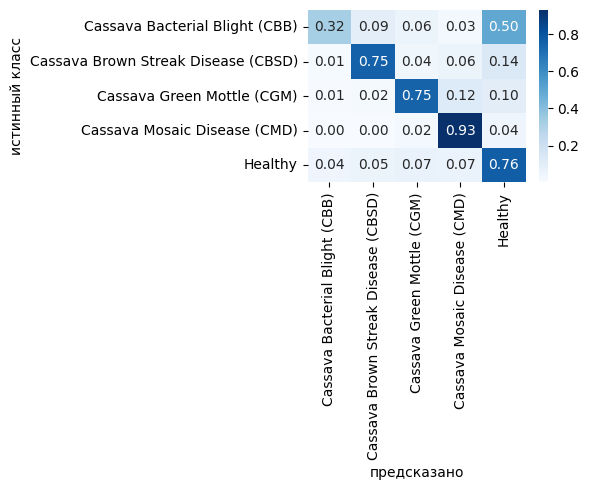

In [17]:
model = timm.create_model(cfg['arch'], pretrained=False, num_classes=5)
model.load_state_dict(torch.load(OUT / 'model.pt', map_location='cpu'))
model.to(DEVICE)

test_df = df[df.split == 'test'].reset_index(drop=True)
logits, y = evaluate(model, make_loader(CassavaDS(test_df, val_tf), bs=128))
probs = logits.softmax(1).numpy()
test_df['pred'] = probs.argmax(1)
test_df['conf'] = probs.max(1)
test_df['ok'] = test_df.pred == test_df.label
test_df['pred_name'] = test_df.pred.map(names)

acc, f1 = metrics(logits, y)
print(f'test accuracy={acc:.4f} macro-F1={f1:.4f}')
print(classification_report(test_df.label, test_df.pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(test_df.label, test_df.pred, normalize='true')
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=CLASSES, yticklabels=CLASSES, cmap='Blues', ax=ax)
ax.set_xlabel('предсказано')
ax.set_ylabel('истинный класс')
plt.tight_layout()
fig.savefig(FIG / 'confusion_matrix.png', dpi=120)

### Разбор ошибок по содержательным группам
1. По парам «истинный класс → предсказанный».
2. По уверенности модели: уверенная ошибка (conf ≥ 0.9) чаще означает неверную метку, неуверенная (conf < 0.6) — трудный или двусмысленный снимок.
3. По яркости снимка (квартили).

In [18]:
pairs = test_df[~test_df.ok].groupby(['label_name', 'pred_name']).size().sort_values(ascending=False)
print(pairs.head(8))

test_df['error_group'] = np.select(
    [test_df.ok, test_df.conf >= 0.9, test_df.conf < 0.6],
    ['верно', 'ошибка, уверенная', 'ошибка, неуверенная'], 'ошибка, средняя уверенность')
print(test_df.error_group.value_counts())
print(test_df.groupby(pd.qcut(test_df.brightness, 4), observed=True).ok.mean().round(3))

label_name                           pred_name                   
Cassava Bacterial Blight (CBB)       Healthy                         58
Cassava Mosaic Disease (CMD)         Healthy                         56
Cassava Green Mottle (CGM)           Cassava Mosaic Disease (CMD)    31
Cassava Mosaic Disease (CMD)         Cassava Green Mottle (CGM)      29
Cassava Green Mottle (CGM)           Healthy                         26
Cassava Brown Streak Disease (CBSD)  Healthy                         26
Healthy                              Cassava Green Mottle (CGM)      18
                                     Cassava Mosaic Disease (CMD)    17
dtype: int64
error_group
верно                          1797
ошибка, средняя уверенность     147
ошибка, неуверенная             134
ошибка, уверенная                62
Name: count, dtype: int64
brightness
(38.806000000000004, 90.357]    0.806
(90.357, 104.947]               0.847
(104.947, 120.635]              0.865
(120.635, 176.669]              0.841


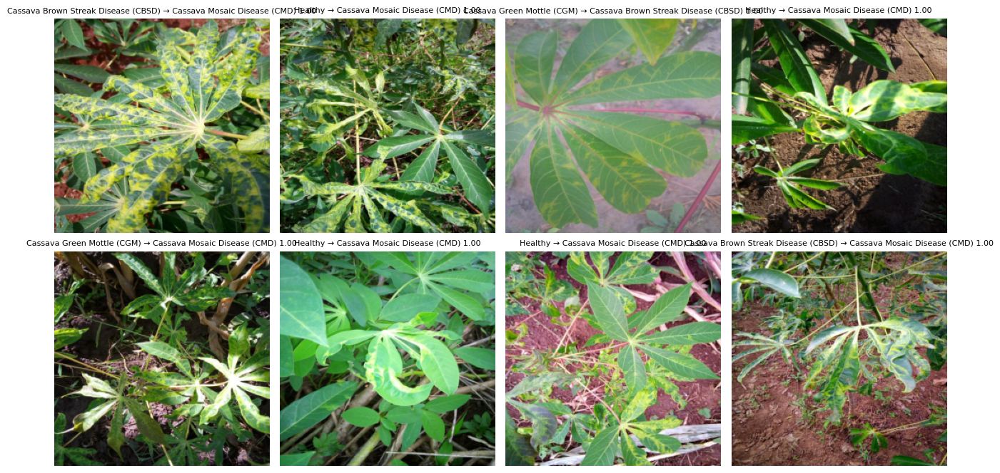

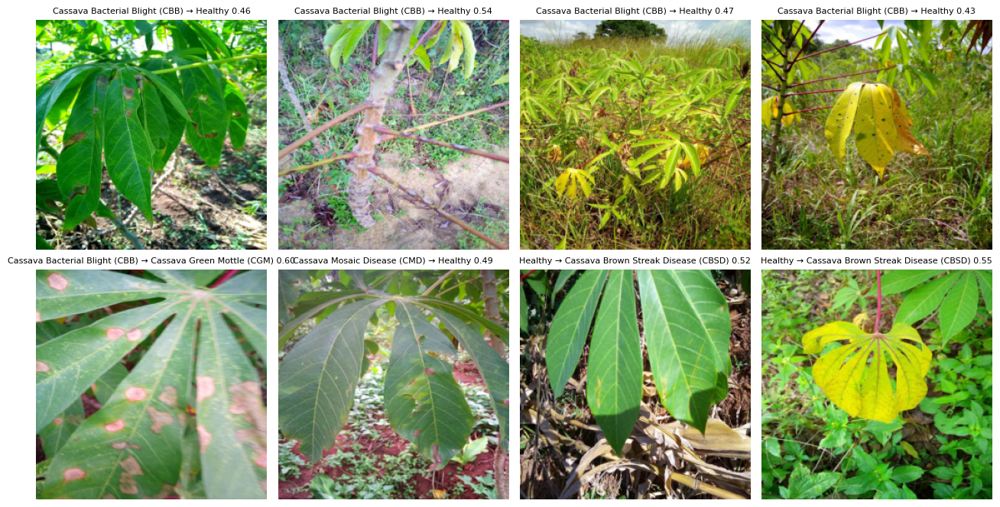

In [19]:
sure = test_df[test_df.error_group == 'ошибка, уверенная'].nlargest(8, 'conf')
show_grid(sure, [f'{r.label_name} → {r.pred_name} {r.conf:.2f}' for r in sure.itertuples()], path=FIG / 'errors_confident.png')

unsure = test_df[test_df.error_group == 'ошибка, неуверенная'].head(8)
show_grid(unsure, [f'{r.label_name} → {r.pred_name} {r.conf:.2f}' for r in unsure.itertuples()], path=FIG / 'errors_unsure.png')

### Устойчивость вне train-распределения
Test-снимки искажаются так, как они могут исказиться у пользователя: тёмный и пересвеченный кадр, смазанная камера, сильное сжатие мессенджером, поворот телефона, низкое разрешение, чёрно-белый кадр, крупный план. Модель при обучении таких искажений не видела (кроме лёгкого изменения яркости и отражений).

In [20]:
shifts = {
    'clean': T.Identity(),
    'dark (x0.4)': T.ColorJitter(brightness=(0.4, 0.4)),
    'bright (x1.8)': T.ColorJitter(brightness=(1.8, 1.8)),
    'blur': T.GaussianBlur(11, sigma=4),
    'jpeg q=10': T.JPEG(quality=(10, 10)),
    'rotate 30°': T.RandomRotation((30, 30)),
    'low-res 48px': T.Compose([T.Resize(48, antialias=True), T.Resize(IMG_SIZE, antialias=True)]),
    'grayscale': T.Grayscale(3),
    'zoom x2': T.Compose([T.CenterCrop(IMG_SIZE // 2), T.Resize(IMG_SIZE, antialias=True)]),
}
rob = []
for name, tf in shifts.items():
    lg, yy = evaluate(model, make_loader(CassavaDS(test_df, T.Compose([tf, val_tf])), bs=128))
    a, f = metrics(lg, yy)
    rob.append(dict(shift=name, accuracy=round(a, 4), macro_f1=round(f, 4)))
rob = pd.DataFrame(rob)
rob['drop_acc'] = (rob.accuracy.iloc[0] - rob.accuracy).round(4)
rob.to_csv(OUT / 'robustness.csv', index=False)
rob

,shift,accuracy,macro_f1,drop_acc
0,clean,0.8397,0.7083,0.0000
1,dark (x0.4),0.7673,0.6502,0.0724
2,bright (x1.8),0.6860,0.5627,0.1537
3,blur,0.3659,0.2456,0.4738
4,jpeg q=10,0.5449,0.4129,0.2948
5,rotate 30°,0.5673,0.4703,0.2724
6,low-res 48px,0.4318,0.2734,0.4079
7,grayscale,0.2150,0.1583,0.6247
8,zoom x2,0.8336,0.7077,0.0061


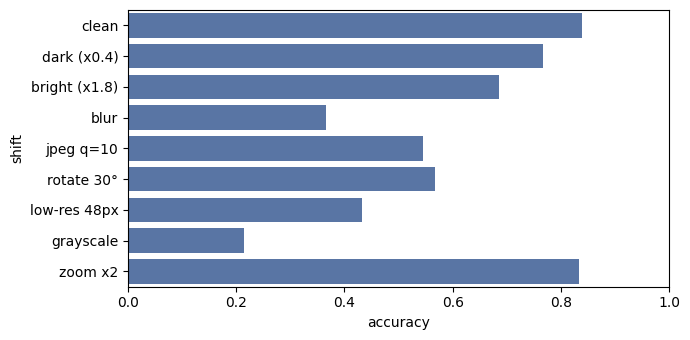

In [21]:
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.barplot(data=rob, y='shift', x='accuracy', ax=ax, color='#4c72b0')
ax.set_xlim(0, 1)
plt.tight_layout()
fig.savefig(FIG / 'robustness.png', dpi=120)

### Ограничения и следующие эксперименты

**Ограничения.**
- Модель различает только 5 классов; другой болезни или другого растения у неё нет, и на такой снимок она всё равно выберет один из пяти классов.
- Метки в датасете шумные (см. уверенные ошибки выше), поэтому потолок accuracy на этих данных ниже 100%.
- Дубликаты находились только по точному совпадению perceptual hash; почти одинаковые снимки с отличающимся хешем могли остаться в разных split.
- Обучение на 256×256: мелкие симптомы на листе при таком уменьшении могут пропадать.
- Единственный запуск на конфигурацию, без повторов с разными seed: разницу меньше 0.5 п.п. нельзя считать значимой.
- Устойчивость проверена на синтетических искажениях test-снимков, а не на фотографиях с другого телефона или поля.

**Следующие эксперименты.**
1. Разрешение 384 или 512 (одна гипотеза: мелкие симптомы теряются при уменьшении).
2. Отбрасывание обучающих снимков с большим loss после первой эпохи (гипотеза: шумные метки вредят).
3. MixUp/CutMix как отдельная гипотеза об аугментациях.
4. 5-fold кросс-валидация и усреднение предсказаний моделей.
5. Калибровка вероятностей (temperature scaling) и порог «не уверен» для передачи снимка эксперту.
6. Добавление искажений из таблицы устойчивости в train transforms.

## Этап 5. Упаковка
Inference выносится в `inference.py`: класс `Classifier` читает `config.json` и `model.pt` рядом с собой, использует `preprocess.py` и принимает пути к файлам.

In [22]:
%%writefile /kaggle/working/cassava_project/inference.py
import argparse
import json
from pathlib import Path

import numpy as np
import timm
import torch

from preprocess import MEAN, STD, load_image

HERE = Path(__file__).parent
IMAGE_EXT = {'.jpg', '.jpeg', '.png'}


class Classifier:
    def __init__(self, device='cpu'):
        cfg = json.loads((HERE / 'config.json').read_text())
        self.classes, self.size, self.device = cfg['classes'], cfg['img_size'], device
        self.model = timm.create_model(cfg['arch'], pretrained=False, num_classes=len(self.classes))
        self.model.load_state_dict(torch.load(HERE / 'model.pt', map_location=device))
        self.model.eval().to(device)
        self.mean = torch.tensor(MEAN).view(1, 3, 1, 1)
        self.std = torch.tensor(STD).view(1, 3, 1, 1)

    def preprocess(self, paths):
        x = np.stack([np.asarray(load_image(p, self.size)) for p in paths])
        x = torch.from_numpy(x).permute(0, 3, 1, 2).float() / 255
        return (x - self.mean) / self.std

    @torch.no_grad()
    def predict(self, paths):
        probs = self.model(self.preprocess(paths).to(self.device)).softmax(1).cpu().numpy()
        return [dict(file=str(p), label=self.classes[int(pr.argmax())], confidence=float(pr.max()),
                     probs={c: float(v) for c, v in zip(self.classes, pr)})
                for p, pr in zip(paths, probs)]


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument('path', help='файл изображения или каталог с изображениями')
    ap.add_argument('--device', default='cpu')
    args = ap.parse_args()
    p = Path(args.path)
    paths = sorted(f for f in p.iterdir() if f.suffix.lower() in IMAGE_EXT) if p.is_dir() else [p]
    print(json.dumps(Classifier(args.device).predict(paths), indent=2, ensure_ascii=False))


if __name__ == '__main__':
    main()

Writing /kaggle/working/cassava_project/inference.py


Проверка: `inference.py` на оригинальных снимках должен давать те же предсказания, что и ноутбук на кэшированных.

In [23]:
from inference import Classifier

clf = Classifier()
chk = test_df.head(48)
out = clf.predict([DATA / 'train_images' / n for n in chk.image_id])
agree = np.mean([o['label'] == p for o, p in zip(out, chk.pred_name)])
print(f'совпадение с ноутбуком: {agree:.3f}')
print(out[0])

совпадение с ноутбуком: 1.000
{'file': '/kaggle/input/competitions/cassava-leaf-disease-classification/train_images/1000723321.jpg', 'label': 'Cassava Brown Streak Disease (CBSD)', 'confidence': 0.466239869594574, 'probs': {'Cassava Bacterial Blight (CBB)': 0.001720175496302545, 'Cassava Brown Streak Disease (CBSD)': 0.466239869594574, 'Cassava Green Mottle (CGM)': 0.0675089880824089, 'Cassava Mosaic Disease (CMD)': 0.07445523142814636, 'Healthy': 0.3900757133960724}}


### Визуальные результаты

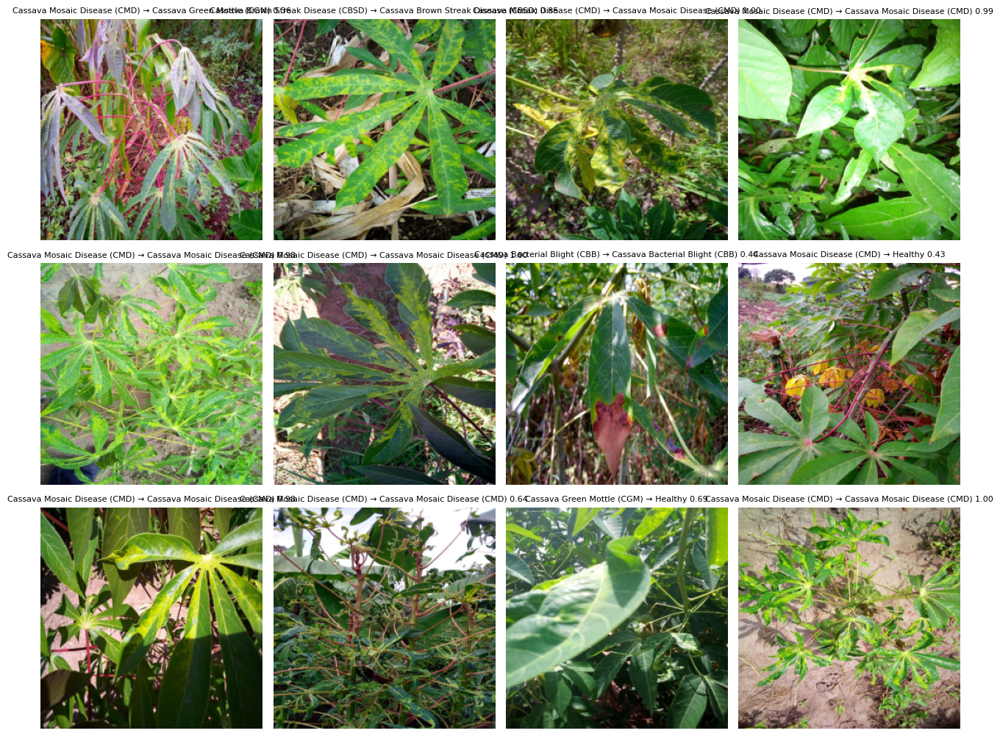

In [24]:
vis = test_df.sample(12, random_state=SEED)
show_grid(vis, [f'{r.label_name} → {r.pred_name} {r.conf:.2f}' for r in vis.itertuples()], path=FIG / 'predictions.png')

### ONNX и проверка ограничений
Экспорт с динамическим размером батча, сравнение выходов с PyTorch, размер файла и время инференса одного снимка на CPU.

In [25]:
import onnxruntime as ort

m = clf.model
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
torch.onnx.export(m, dummy, OUT / 'model.onnx', input_names=['image'], output_names=['logits'],
                  dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}}, opset_version=17, dynamo=False)

sess = ort.InferenceSession(str(OUT / 'model.onnx'), providers=['CPUExecutionProvider'])
x = clf.preprocess([DATA / 'train_images' / n for n in chk.image_id[:8]])
with torch.no_grad():
    ref = m(x).numpy()
onnx_out = sess.run(None, {'image': x.numpy()})[0]
print('max |torch - onnx|:', np.abs(ref - onnx_out).max())


def latency(fn, n=20):
    fn()
    t = time.perf_counter()
    for _ in range(n):
        fn()
    return (time.perf_counter() - t) / n * 1000


one = x[:1]
t_torch = latency(lambda: m(one))
t_onnx = latency(lambda: sess.run(None, {'image': one.numpy()}))
size_pt = (OUT / 'model.pt').stat().st_size / 1e6
size_onnx = (OUT / 'model.onnx').stat().st_size / 1e6
print(f'PyTorch CPU: {t_torch:.0f} мс, ONNX CPU: {t_onnx:.0f} мс')
print(f'model.pt: {size_pt:.1f} МБ, model.onnx: {size_onnx:.1f} МБ')
print('ограничения выполнены:', size_pt <= 50 and min(t_torch, t_onnx) <= 500)

/tmp/ipykernel_23/1838125773.py:5: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(m, dummy, OUT / 'model.onnx', input_names=['image'], output_names=['logits'],


max |torch - onnx|: 2.4795532e-05
PyTorch CPU: 52 мс, ONNX CPU: 20 мс
model.pt: 16.4 МБ, model.onnx: 16.0 МБ
ограничения выполнены: True


### README и список зависимостей

In [26]:
table = res[['name', 'hypothesis', 'epochs', 'lr', 'smoothing', 'params_m', 'train_min', 'val_acc', 'val_f1']].round(4)
readme = f"""# Cassava Leaf Disease Classification

Классификация фотографии листа маниоки на 5 классов: {', '.join(CLASSES)}.
Модель: `{cfg['arch']}` (timm), вход 256×256 RGB.

## Результаты

Test (10% данных, split по группам дубликатов): accuracy **{acc:.4f}**, macro-F1 **{f1:.4f}**.

Эксперименты на validation:

{table.to_markdown(index=False)}

Устойчивость к искажениям test-снимков: `robustness.csv`, `figures/robustness.png`.

## Установка

```bash
pip install -r requirements.txt
```

## Структура

```
cassava_project/
├── model.pt            веса лучшей модели
├── model.onnx          та же модель в ONNX
├── config.json         архитектура, классы, размер входа, параметры обучения
├── preprocess.py       изменение размера и константы нормализации
├── inference.py        класс Classifier и CLI
├── experiments.csv     таблица экспериментов
├── robustness.csv      метрики на искажённых снимках
├── split.csv           разбиение на train/val/test
├── checkpoints/        лучшие веса каждого эксперимента
└── figures/            рисунки EDA, ошибок и предсказаний
```

Данные обучения: `train.csv`, `train_images/`, `label_num_to_disease_map.json` соревнования
`cassava-leaf-disease-classification`.

## Запуск на новых снимках

```bash
python inference.py photo.jpg
python inference.py folder_with_photos/ --device cuda
```

```python
from inference import Classifier
print(Classifier().predict(['photo.jpg']))
```

Предобработка: изменение размера до 256×256 (bilinear), деление на 255, нормализация средним и
стандартным отклонением ImageNet. Выполняется внутри `Classifier`.

ONNX: вход `image` (batch, 3, 256, 256) float32 после той же предобработки, выход `logits` (batch, 5).

## Ограничения

Пять классов, других болезней и растений нет; метки датасета шумные; обучение на 256×256;
устойчивость проверена на синтетических искажениях.
"""
(OUT / 'README.md').write_text(readme, encoding='utf-8')
(OUT / 'requirements.txt').write_text(
    f'torch\ntorchvision\ntimm=={timm.__version__}\nnumpy\npillow\nonnxruntime\n')
print(sorted(p.name for p in OUT.iterdir()))

['README.md', '__pycache__', 'checkpoints', 'config.json', 'experiments.csv', 'figures', 'inference.py', 'model.onnx', 'model.pt', 'preprocess.py', 'requirements.txt', 'robustness.csv', 'split.csv', 'train_meta.csv']
